In [ ]:
!pip install sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.3 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier

import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)

# Reading the Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PR/BAITAPNHOM/turkishCF.csv', sep=';', on_bad_lines='skip')

In [ ]:
df.head()

,id,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,yorumlar,destekci_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,toplanan_tutar,destek_orani,basari_durumu
0,1,fongogo,ödül,diğer,ya hep ya hiç,Gerçek Gizlidir Filmleri,Lob Ekibi,belirsiz,1,0,1,0,istanbul,marmara,2014,15.09.2014,16.11.2014,62,var,104,1,0,4,0,150,11,4,yok,var,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,başarılı
1,2,fongogo,ödül,diğer,ya hep ya hiç,Fongogo - Hayat Bulsun!,Fongogo Team,belirsiz,3,0,2,0,istanbul,marmara,2015,4.05.2015,3.07.2015,60,yok,0,12,0,0,0,51,11,7,yok,var,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,başarılı
2,3,fongogo,ödül,diğer,ya hep ya hiç,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",SİNEM CAN,kadın,0,0,2,1,belirsiz,belirsiz,2017,NaN,13.06.2017,60,var,60,8,1,1,1,25,6,2,var,var,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,101%,başarılı
3,4,fongogo,ödül,diğer,ya hep ya hiç,Türk Kadının 100.yıl Seyri,Deniz Tutkusu Seyirde,kadın,0,0,1,0,muğla,ege,2019,19.04.2019,18.06.2019,60,var,67,6,0,0,0,45,7,1,var,var,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,101%,başarılı
4,5,fongogo,ödül,diğer,ya hep ya hiç,Doğadaki Çocuk,Seren Kutadgu,kadın,2,0,1,0,istanbul,marmara,2019,2.09.2019,1.11.2019,60,var,149,5,0,0,0,105,8,6,yok,var,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,104%,başarılı


In [ ]:
#đổi tên các cột trong DataFrame
rename_dict = {
    'platform_adi': 'platform_name',
    'kitle_fonlamasi_turu': 'crowdfunding_type',
    'kategori': 'category',
    'fon_sekli': 'fund_type',
    'proje_adi': 'project_name',
    'proje_sahibi': 'project_owner',
    'proje_sahibi_cinsiyet': 'project_owner_gender',
    'kac_proje_destekledi': 'number_of_supported_projects',
    'kac_projeye_abone': 'number_of_subscribed_projects',
    'kac_projenin_sahibi': 'number_of_projects_owners',
    'kac_proje_takiminda': 'number_of_team_members_in_projects',
    'konum': 'location',
    'bolge': 'region',
    'yil': 'year',
    'proje_baslama_tarihi': 'project_start_date',
    'proje_bitis_tarihi': 'project_end_date',
    'gun_sayisi': 'number_of_days',
    'tanitim_videosu': 'promotion_video',
    'video_uzunlugu': 'video_length',
    'gorsel_sayisi': 'number_of_images',
    'sss': 'faq',
    'guncellemeler': 'updates',
    'yorumlar': 'comments',
    'destekci_sayisi': 'number_of_supporters',
    'odul_sayisi': 'number_of_awards',
    'ekip_kisi_sayisi': 'number_of_team_members',
    'web_sitesi': 'website',
    'sosyal_medya': 'social_media',
    'sm_sayisi': 'number_of_social_media_accounts',
    'sm_takipci': 'social_media_followers',
    'etiket_sayisi': 'number_of_tags',
    'icerik_kelime_sayisi': 'number_of_words_in_content',
    'proje_aciklamasi': 'project_description',
    'hedef_miktari': 'target_amount',
    'toplanan_tutar': 'amount_collected',
    'destek_orani': 'support_rate',
    'basari_durumu': 'success_status'
}

df.rename(columns=rename_dict, inplace=True)

In [ ]:
# thay thế giá trị trong các cột của một DataFrame pandas theo các quy tắc được định nghĩa trong các từ điển (rename_dict, var_yok_rename, v.v.).
var_yok_rename = {'var': 'yes', 'yok': 'no'}
success_status_rename = {'başarılı': 'successful', 'başarısız': 'unsuccessful'}
category_rename = {
    'film-video-fotoğraf': 'film-video-photography',
    'teknoloji': 'technology',
    'kültür-sanat': 'culture-arts',
    'eğitim': 'education',
    'diğer': 'other',
    'çevre': 'environment',
    'müzik': 'music',
    'sağlık-güzellik': 'health-beauty',
    'tasarım': 'design',
    'yayıncılık': 'publishing',
    'gıda-yeme-içme': 'food-drink',
    'spor': 'sports',
    'hayvanlar': 'animals',
    'moda': 'fashion',
    'sosyal sorumluluk': 'social-responsibility',
    'dans-performans': 'dance-performance',
    'turizm': 'tourism'
}
kitle_fonlamasi_turu_rename = {
    'ödül': 'reward',
    'bağış': 'donation'
}
fon_sekli_rename = {
    'ya hep ya hiç': 'all or nothing',
    'hepsi kalsın': 'flexible'
}
proje_sahibi_rename = {
    'erkek': 'male',
    'kadın': 'female',
    'belirsiz': 'unknown'
}
bolge_rename = {
    'marmara': 'Marmara',
    'ege': 'Aegean',
    'akdeniz': 'Mediterranean',
    'iç anadolu': 'Central Anatolia',
    'doğu anadolu': 'Eastern Anatolia',
    'güneydoğu anadolu': 'Southeastern Anatolia',
    'karadeniz': 'Black Sea',
    'belirsiz': 'unknown',
    'genel': 'unknown'
}


df['promotion_video'] = df['promotion_video'].map(var_yok_rename)
df['website'] = df['website'].map(var_yok_rename)
df['social_media'] = df['social_media'].map(var_yok_rename)
df['success_status'] = df['success_status'].map(success_status_rename)
df['category'] = df['category'].map(category_rename)
df['crowdfunding_type'] = df['crowdfunding_type'].map(kitle_fonlamasi_turu_rename)
df['fund_type'] = df['fund_type'].map(fon_sekli_rename)
df['project_owner_gender'] = df['project_owner_gender'].map(proje_sahibi_rename)
df['region'] = df['region'].map(bolge_rename)



In [ ]:
df.head()

,id,platform_name,crowdfunding_type,category,fund_type,project_name,project_owner,project_owner_gender,number_of_supported_projects,number_of_subscribed_projects,number_of_projects_owners,number_of_team_members_in_projects,location,region,year,project_start_date,project_end_date,number_of_days,promotion_video,video_length,number_of_images,faq,updates,comments,number_of_supporters,number_of_awards,number_of_team_members,website,social_media,number_of_social_media_accounts,social_media_followers,number_of_tags,number_of_words_in_content,project_description,target_amount,amount_collected,support_rate,success_status
0,1,fongogo,reward,other,all or nothing,Gerçek Gizlidir Filmleri,Lob Ekibi,unknown,1,0,1,0,istanbul,Marmara,2014,15.09.2014,16.11.2014,62,yes,104,1,0,4,0,150,11,4,no,yes,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,successful
1,2,fongogo,reward,other,all or nothing,Fongogo - Hayat Bulsun!,Fongogo Team,unknown,3,0,2,0,istanbul,Marmara,2015,4.05.2015,3.07.2015,60,no,0,12,0,0,0,51,11,7,no,yes,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,successful
2,3,fongogo,reward,other,all or nothing,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",SİNEM CAN,female,0,0,2,1,belirsiz,unknown,2017,NaN,13.06.2017,60,yes,60,8,1,1,1,25,6,2,yes,yes,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,101%,successful
3,4,fongogo,reward,other,all or nothing,Türk Kadının 100.yıl Seyri,Deniz Tutkusu Seyirde,female,0,0,1,0,muğla,Aegean,2019,19.04.2019,18.06.2019,60,yes,67,6,0,0,0,45,7,1,yes,yes,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,101%,successful
4,5,fongogo,reward,other,all or nothing,Doğadaki Çocuk,Seren Kutadgu,female,2,0,1,0,istanbul,Marmara,2019,2.09.2019,1.11.2019,60,yes,149,5,0,0,0,105,8,6,no,yes,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,104%,successful


In [ ]:
# Ghi chú: Xóa cột 'id' và 'project_owner' vì:
# 1. 'id' chỉ là mã định danh, không mang giá trị thông tin hữu ích.
# 2. 'project_owner' có thể không liên quan trực tiếp hoặc gây rủi ro rò rỉ thông tin.
df.drop(columns=['id','project_owner'], inplace=True)

In [ ]:
# Chuyển đổi cột 'project_end_date' sang kiểu datetime
df['project_end_date'] = df['project_end_date'].replace({'18.Oca.16': '18.01.2016'})

In [ ]:
# Chuyển đổi cột ngày sang kiểu dữ liệu datetime
df['project_start_date'] = pd.to_datetime(df['project_start_date'])
df['project_end_date'] = pd.to_datetime(df['project_end_date'], format='mixed', dayfirst=True)

# Chuẩn hóa tỷ lệ hỗ trợ (support_rate)
# Loại bỏ ký hiệu % khỏi cột support_rate
# Thay thế ký hiệu % bằng chuỗi rỗng để chuẩn bị chuyển đổi dữ liệu từ chuỗi sang số
df['support_rate'] = df['support_rate'].str.replace('%', '')
df['support_rate'] = df['support_rate'].astype(float) / 100

In [ ]:
df.describe()

,number_of_supported_projects,number_of_subscribed_projects,number_of_projects_owners,number_of_team_members_in_projects,year,project_start_date,project_end_date,number_of_days,video_length,number_of_images,faq,updates,comments,number_of_supporters,number_of_awards,number_of_team_members,number_of_social_media_accounts,social_media_followers,number_of_tags,number_of_words_in_content,target_amount,amount_collected,support_rate
count,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1017,1075,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1.628000e+03,1628.000000
mean,0.429361,0.000614,1.165848,0.052826,2018.042383,2018-10-21 03:11:09.026548736,2018-11-21 16:41:58.325581056,52.004914,67.668305,5.036855,0.203317,0.512899,1.295455,24.084767,5.979730,1.810197,1.033170,2541.066953,1.374693,354.221744,3.113431e+04,1.142884e+04,0.392230
min,0.000000,0.000000,1.000000,0.000000,2011.000000,2013-12-02 00:00:00,2014-01-07 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000,1.000000,0.000000,2017.000000,2018-03-19 00:00:00,2017-12-31 00:00:00,45.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,134.750000,6.150000e+03,0.000000e+00,0.000000
50%,0.000000,0.000000,1.000000,0.000000,2019.000000,2019-05-19 00:00:00,2019-06-17 00:00:00,60.000000,46.000000,3.000000,0.000000,0.000000,0.000000,3.000000,6.000000,1.000000,1.000000,4.000000,0.000000,277.500000,1.500000e+04,2.500000e+02,0.020000
75%,0.000000,0.000000,1.000000,0.000000,2020.000000,2020-03-18 00:00:00,2020-05-01 00:00:00,60.000000,98.250000,7.000000,0.000000,0.000000,0.000000,18.000000,8.000000,2.000000,2.000000,498.250000,4.000000,464.250000,3.500000e+04,4.207500e+03,0.435000
max,31.000000,1.000000,7.000000,4.000000,2021.000000,2021-01-22 00:00:00,2021-03-09 00:00:00,118.000000,1651.000000,221.000000,30.000000,71.000000,400.000000,1994.000000,29.000000,28.000000,4.000000,534300.000000,12.000000,3473.000000,1.453000e+06,2.666800e+06,113.000000
std,2.225029,0.024784,0.710455,0.244744,2.054583,NaN,NaN,15.294526,108.145452,7.842166,1.439136,2.409611,12.214556,82.257217,2.231298,1.851983,1.225174,19468.390705,2.142645,300.196873,6.568972e+04,8.474755e+04,2.904456


In [ ]:
# Hiển thị thống kê mô tả cho các cột kiểu object, chia thành từng nhóm 20 cột
for i in range(0,36,20):
    display(df[df.columns[i:i+20]].describe(include = ['object']))

,platform_name,crowdfunding_type,category,fund_type,project_name,project_owner_gender,location,region,promotion_video
count,1628,1628,1628,1628,1628,1628,1628,1562,1628
unique,6,2,17,2,1607,3,66,6,2
top,fongogo,reward,film-video-photography,all or nothing,QUBİT'E HAYAL ORTAĞI OLUN,male,istanbul,Marmara,yes
freq,1075,1618,389,1509,3,1148,547,638,947


,website,social_media,project_description,success_status
count,1628,1628,1628,1628
unique,2,2,1608,2
top,no,yes,Tüm güzellik hizmeti veren işletmeler gibi zor...,unsuccessful
freq,1212,833,6,1252


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   platform_name                       1628 non-null   object        
 1   crowdfunding_type                   1628 non-null   object        
 2   category                            1628 non-null   object        
 3   fund_type                           1628 non-null   object        
 4   project_name                        1628 non-null   object        
 5   project_owner_gender                1628 non-null   object        
 6   number_of_supported_projects        1628 non-null   int64         
 7   number_of_subscribed_projects       1628 non-null   int64         
 8   number_of_projects_owners           1628 non-null   int64         
 9   number_of_team_members_in_projects  1628 non-null   int64         
 10  location                

In [ ]:
# kiểm tra dữ liệu bị thiếu
df.isna().sum().sort_values(ascending=False)

,0
project_start_date,611
project_end_date,553
region,66
platform_name,0
fund_type,0
category,0
crowdfunding_type,0
project_name,0
number_of_subscribed_projects,0
number_of_projects_owners,0


In [ ]:
# đếm số lượng các giá trị duy nhất xuất hiện trong cột number_of_subscribed_projects
df['number_of_subscribed_projects'].value_counts()

,count
number_of_subscribed_projects,
0,1627
1,1


In [ ]:
df.drop('number_of_subscribed_projects', axis=1, inplace=True)
#trả về giá trị cho thấy cột không đóng góp nhiều vào bài toán

# Phân tích tỷ lệ thành công và thất bại cho các cột phân loại nhị phân

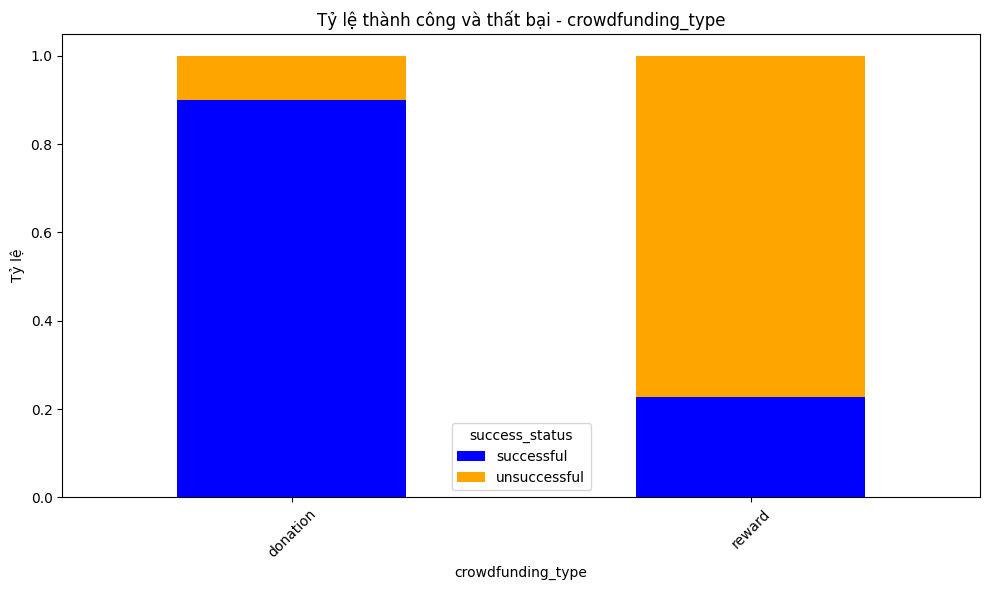

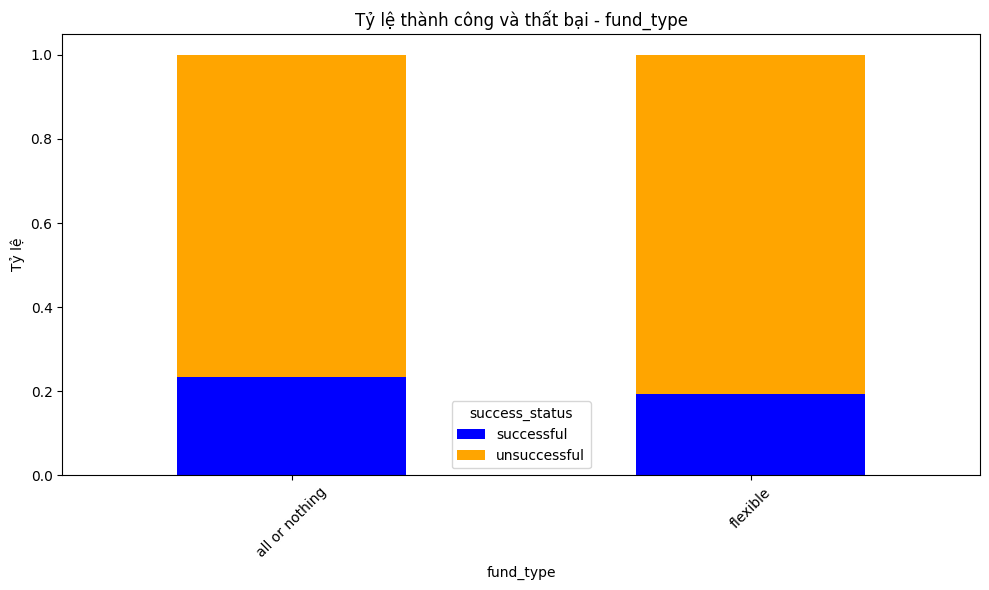

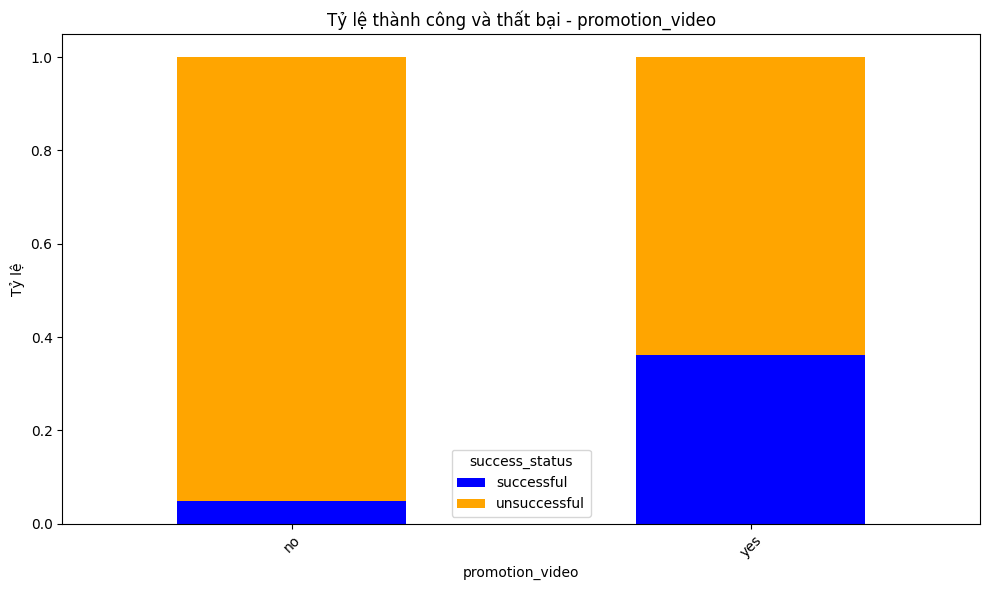

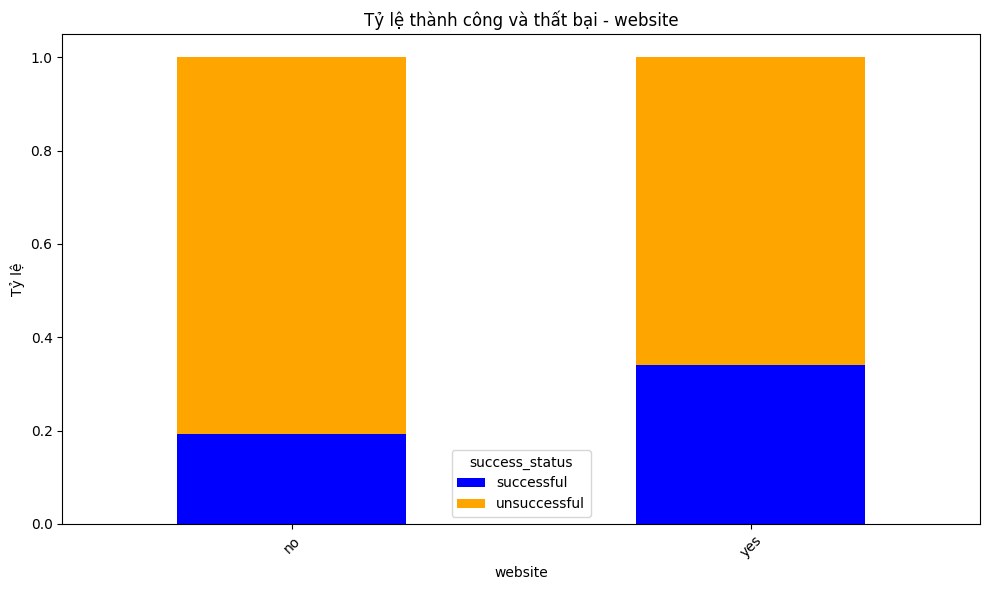

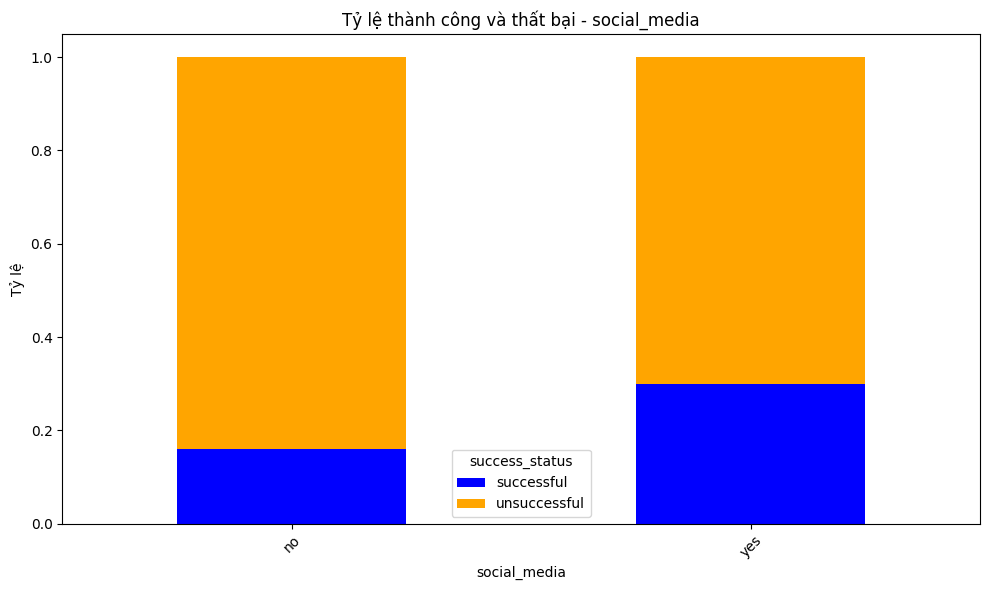

In [ ]:
# Tìm các cột danh mục nhị phân
categorical_columns = [col for col in df.columns if df[col].nunique() == 2 and col != 'success_status']

for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    # Tính số lượng thành công và thất bại
    success_fail_counts = df.groupby([col, 'success_status']).size().unstack(fill_value=0)
    # Tính tỷ lệ thành công và thất bại
    success_fail_ratios = success_fail_counts.div(success_fail_counts.sum(axis=1), axis=0)

    success_fail_ratios.plot(kind='bar', stacked=True, color=['blue', 'orange'], ax=plt.gca())

    plt.title(f"Tỷ lệ thành công và thất bại - {col}")
    plt.ylabel("Tỷ lệ")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Hiểu rõ sự phân phối của các giá trị trong các cột nhị phân:

Các cột nhị phân có thể mang lại thông tin quan trọng về các thuộc tính của dự án (như "Is Project Funded" hoặc "Has Video" trong dữ liệu crowdfunding). Việc phân tích tỷ lệ thành công và thất bại cho các giá trị này giúp bạn xác định liệu có sự liên kết nào giữa các yếu tố đặc thù (ví dụ, có video hay không) và tỷ lệ thành công của dự án.

Phát hiện mối quan hệ giữa đặc tính nhị phân và mục tiêu (target variable):

Trong trường hợp của bạn, success_status là cột mục tiêu, biểu thị việc dự án thành công hay thất bại. Việc phân tích các cột nhị phân giúp bạn hiểu xem các đặc tính này có ảnh hưởng đến khả năng thành công của dự án không. Ví dụ, nếu một dự án có video, tỷ lệ thành công có thể cao hơn, và việc phân tích có thể chỉ ra điều này.

Xác định các yếu tố có ảnh hưởng lớn đến kết quả:

Phân tích tỷ lệ thành công cho từng giá trị của các cột nhị phân giúp bạn nhận diện các yếu tố có ảnh hưởng mạnh đến dự án. Ví dụ, nếu một yếu tố như "Has Image" có ảnh hưởng lớn đến sự thành công của dự án, bạn có thể tập trung vào các dự án có yếu tố này để tối ưu hóa chiến lược.

Hỗ trợ mô hình hóa và lựa chọn đặc trưng:

Các yếu tố nhị phân có thể là đặc trưng quan trọng trong mô hình dự đoán. Việc phân tích tỷ lệ thành công giúp bạn lựa chọn đặc trưng hiệu quả cho mô hình phân loại, giúp cải thiện độ chính xác và khả năng giải thích của mô hình.

Đảm bảo rằng không có sự mất cân đối giữa các lớp:

Khi phân tích tỷ lệ thành công cho các cột nhị phân, bạn cũng có thể kiểm tra xem có sự mất cân đối trong các lớp của đặc trưng hay không. Điều này đặc biệt quan trọng trong việc huấn luyện mô hình học máy, vì sự mất cân đối có thể gây ra độ chính xác thấp hoặc làm sai lệch kết quả.

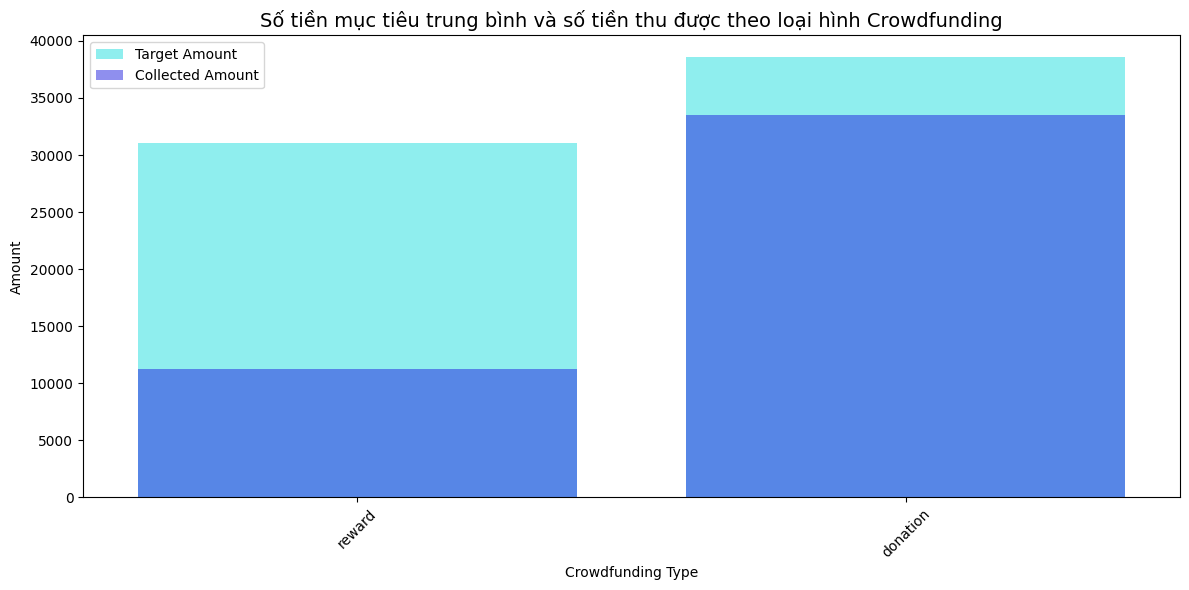

In [ ]:
# Tạo biểu đồ thanh so sánh target_amount và amount_collected theo loại hình crowdfunding
plt.figure(figsize=(12, 6))
sns.barplot(x='crowdfunding_type', y='target_amount', data=df, estimator='mean', ci=None,color='cyan', alpha=0.5, label='Target Amount')
sns.barplot(x='crowdfunding_type', y='amount_collected', data=df, estimator='mean', ci=None, color='blue', alpha=0.5, label='Collected Amount')
plt.title('Số tiền mục tiêu trung bình và số tiền thu được theo loại hình Crowdfunding', fontsize=14)
plt.xlabel('Crowdfunding Type')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ giúp bạn so sánh số tiền mục tiêu và số tiền thu được của các dự án crowdfunding theo từng loại hình. Việc so sánh này có thể giúp nhận diện sự khác biệt giữa các loại hình crowdfunding về số tiền mà họ kỳ vọng và số tiền thực tế thu được. Đây là một cách để phân tích hiệu quả của các chiến dịch crowdfunding khác nhau, từ đó có thể đưa ra chiến lược phù hợp cho các dự án tiếp theo.

<Figure size 1000x600 with 0 Axes>

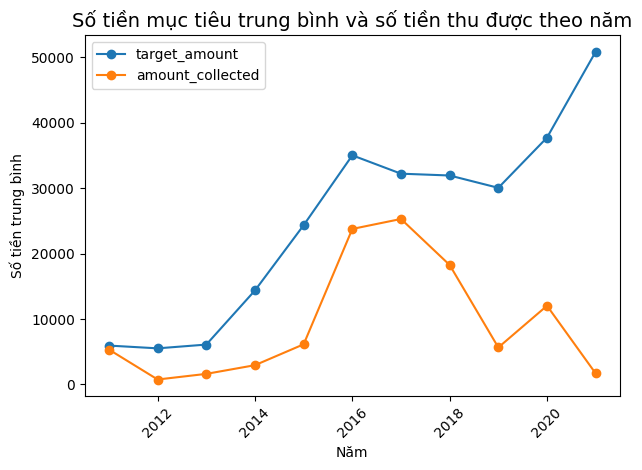

In [ ]:
# so sánh số tiền trung bình theo năm
year_average = df.groupby('year')[['target_amount', 'amount_collected']].mean()

plt.figure(figsize=(10, 6))
year_average.plot(kind='line', marker='o')
plt.title('Số tiền mục tiêu trung bình và số tiền thu được theo năm', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Số tiền trung bình')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ này giúp bạn theo dõi sự thay đổi của số tiền mục tiêu và số tiền thu được qua các năm. Bạn có thể nhận thấy các xu hướng chung như sự gia tăng hoặc giảm sút của số tiền thu được so với mục tiêu qua thời gian. Điều này có thể giúp bạn đánh giá hiệu quả của các chiến dịch crowdfunding trong từng năm.



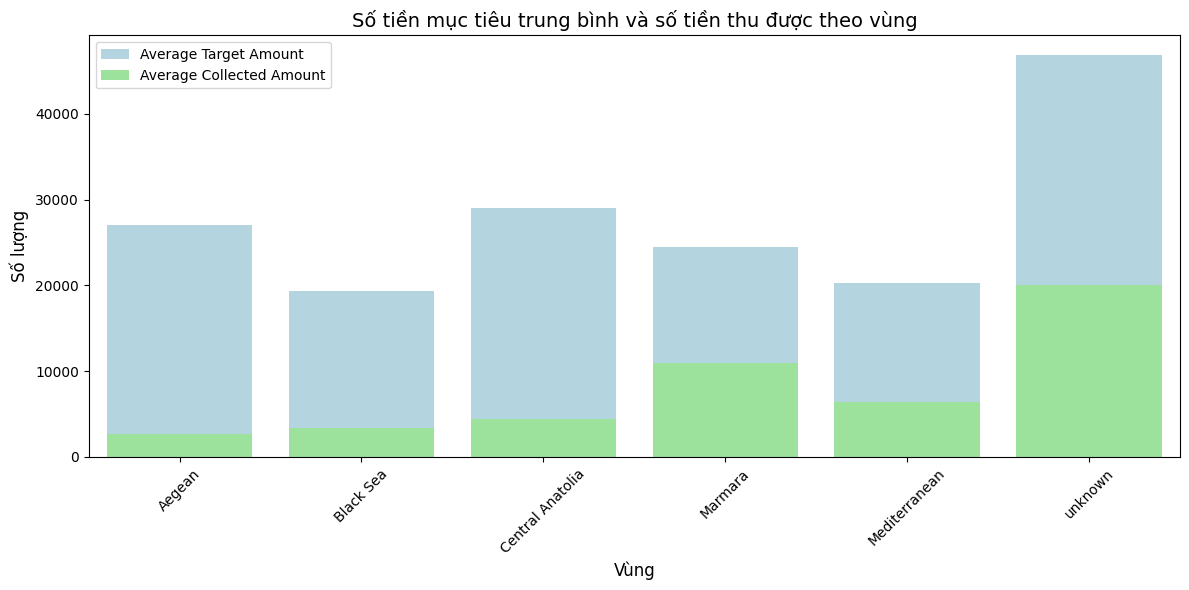

In [ ]:
# so sánh số tiền mục tiêu trung bình và số tiền huy động trung bình theo từng vùng
amount_by_region = df.groupby('region')[['target_amount', 'amount_collected']].mean().reset_index()


plt.figure(figsize=(12, 6))


sns.barplot(x='region', y='target_amount', data=amount_by_region, color='lightblue', label='Average Target Amount', ci=None)
sns.barplot(x='region', y='amount_collected', data=amount_by_region, color='lightgreen', label='Average Collected Amount', ci=None)

plt.title('Số tiền mục tiêu trung bình và số tiền thu được theo vùng', fontsize=14)
plt.xlabel('Vùng', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Biểu đồ sẽ giúp bạn so sánh số tiền mục tiêu trung bình và số tiền thu được trung bình theo từng vùng. Bạn có thể dễ dàng nhận thấy vùng nào có mức huy động tài chính cao hơn hoặc vùng nào không đạt được số tiền mục tiêu kỳ vọng.

# Preprocessing

In [ ]:
# Kiểm tra giá trị bị thiếu
df.isna().sum().sort_values(ascending=False)

,0
project_start_date,611
project_end_date,553
region,66
category,0
crowdfunding_type,0
platform_name,0
fund_type,0
number_of_supported_projects,0
number_of_projects_owners,0
project_owner_gender,0


In [ ]:
# điền giá trị thiếu (NaN) trong cột region bằng giá trị xuất hiện nhiều nhất (mode) trong cột đó
df['region'].fillna(df['region'].mode()[0], inplace=True)

In [ ]:
# thay thế tất cả các giá trị thiếu (NaN) trong DataFrame df bằng giá trị 0
df.fillna(0, inplace=True)

In [ ]:
# chuyển đổi các giá trị phân loại (categorical values) thành các số nguyên
encoder = LabelEncoder()

columns_to_encode = ['platform_name', 'crowdfunding_type','project_owner_gender' ,'category', 'fund_type', 'location', 'region']

for col in columns_to_encode:
    df[col] = df[col].replace('unknown', 0).astype(str)
    df[col] = encoder.fit_transform(df[col])


In [ ]:
# chuyển đổi các giá trị chuỗi như 'yes', 'no', 'successful', và 'unsuccessful' thành các giá trị số (1 và 0)
yes_no_mapping = {'yes': 1, 'no': 0}
success_status_mapping = {'successful': 1, 'unsuccessful': 0}

df['promotion_video'] = df['promotion_video'].map(yes_no_mapping)
df['website'] = df['website'].map(yes_no_mapping)
df['social_media'] = df['social_media'].map(yes_no_mapping)
df['success_status'] = df['success_status'].map(success_status_mapping)

In [ ]:
df.head()

,platform_name,crowdfunding_type,category,fund_type,project_name,project_owner_gender,number_of_supported_projects,number_of_projects_owners,number_of_team_members_in_projects,location,region,year,project_start_date,project_end_date,number_of_days,promotion_video,video_length,number_of_images,faq,updates,comments,number_of_supporters,number_of_awards,number_of_team_members,website,social_media,number_of_social_media_accounts,social_media_followers,number_of_tags,number_of_words_in_content,project_description,target_amount,amount_collected,support_rate,success_status
0,4,1,11,0,Gerçek Gizlidir Filmleri,0,1,1,0,26,4,2014,2014-09-15 00:00:00,2014-11-16 00:00:00,62,1,104,1,0,4,0,150,11,4,0,1,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,1.36,1
1,4,1,11,0,Fongogo - Hayat Bulsun!,0,3,2,0,26,4,2015,2015-05-04 00:00:00,2015-07-03 00:00:00,60,0,0,12,0,0,0,51,11,7,0,1,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,1.00,1
2,4,1,11,0,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",1,0,2,1,13,0,2017,0,2017-06-13 00:00:00,60,1,60,8,1,1,1,25,6,2,1,1,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,1.01,1
3,4,1,11,0,Türk Kadının 100.yıl Seyri,1,0,1,0,42,1,2019,2019-04-19 00:00:00,2019-06-18 00:00:00,60,1,67,6,0,0,0,45,7,1,1,1,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,1.01,1
4,4,1,11,0,Doğadaki Çocuk,1,2,1,0,26,4,2019,2019-09-02 00:00:00,2019-11-01 00:00:00,60,1,149,5,0,0,0,105,8,6,0,1,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,1.04,1


# NLP - Bert

In [ ]:
# sử dụng mô hình SentenceTransformer để tạo ra các đặc trưng (embedding) cho hai cột văn bản trong DataFrame ('project_description' và 'project_name')
sentence_transformer_model = SentenceTransformer("dbmdz/bert-base-turkish-128k-uncased")

# Tạo embedding cho cột 'project_description' và 'project_name'
df_embeddings_description = sentence_transformer_model.encode(df['project_description'].fillna(""))
df_embeddings_name = sentence_transformer_model.encode(df['project_name'].fillna(""))

# # Thêm các đặc trưng (embedding) vào DataFrame
df[[f"nn_emb_desc_{i}" for i in range(df_embeddings_description.shape[1])]] = df_embeddings_description
df[[f"nn_emb_name_{i}" for i in range(df_embeddings_name.shape[1])]] = df_embeddings_name

config.json:   0%|          | 0.00/386 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/740M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

In [ ]:
df.head()

platform_name  crowdfunding_type  category  fund_type  \
0              4                  1        11          0   
1              4                  1        11          0   
2              4                  1        11          0   
3              4                  1        11          0   
4              4                  1        11          0   

                                        project_name  project_owner_gender  \
0                           Gerçek Gizlidir Filmleri                     0   
1                            Fongogo - Hayat Bulsun!                     0   
2  PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...                     1   
3                         Türk Kadının 100.yıl Seyri                     1   
4                                     Doğadaki Çocuk                     1   

   number_of_supported_projects  number_of_projects_owners  \
0                             1                          1   
1                             3                          2   
2                             0                          2   
3                             0                          1   
4                             2                          1   

   number_of_team_members_in_projects  location  region  year  \
0                                   0        26       4  2014   
1                                   0        26       4  2015   
2                                   1        13       0  2017   
3                                   0        42       1  2019   
4                                   0        26       4  2019   

    project_start_date     project_end_date  number_of_days  promotion_video  \
0  2014-09-15 00:00:00  2014-11-16 00:00:00              62                1   
1  2015-05-04 00:00:00  2015-07-03 00:00:00              60                0   
2                    0  2017-06-13 00:00:00              60                1   
3  2019-04-19 00:00:00  2019-06-18 00:00:00              60                1   
4  2019-09-02 00:00:00  2019-11-01 00:00:00              60                1   

   video_length  number_of_images  faq  updates  comments  \
0           104                 1    0        4         0   
1             0                12    0        0         0   
2            60                 8    1        1         1   
3            67                 6    0        0         0   
4           149                 5    0        0         0   

   number_of_supporters  number_of_awards  number_of_team_members  website  \
0                   150                11                       4        0   
1                    51                11                       7        0   
2                    25                 6                       2        1   
3                    45                 7                       1        1   
4                   105                 8                       6        0   

   social_media  number_of_social_media_accounts  social_media_followers  \
0             1                                3                     274   
1             1                                3                    5634   
2             1                                2                     510   
3             1                                2                    3338   
4             1                                1                     144   

   number_of_tags  number_of_words_in_content  \
0               0                         301   
1               0                         167   
2               4                         413   
3               5                         287   
4               3                         571   

                                 project_description  target_amount  \
0  Türkiye’de ilk kez her aşaması ‘online’ olarak...          40000   
1  Fongogo ekibi olarak büyümek, daha geniş kitle...          50000   
2  Çocuklara her şeyin ücretsiz olduğu iyilik evi...          47000   
3  ‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...    

In [ ]:
df.drop(columns=['project_name', 'project_description'], inplace=True)

# Training

**The 'support_rate' column needs to be removed from the features because the column is excessively related to the target variable.**

In [ ]:
# Đặt mục tiêu (y)
y = df['success_status']

# Chuẩn bị dữ liệu đầu vào (X)
X = df.drop(columns=['success_status', 'project_start_date', 'project_end_date','support_rate'])

In [ ]:
#  tìm các chỉ số của các cột trong X có kiểu dữ liệu là chuỗi (object), tức là các cột phân loại (categorical features)
categorical_features_indices = np.where(X.dtypes == 'object')[0]

In [ ]:
'''def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 1e5, log=True),
        'border_count': trial.suggest_int('border_count', 1, 255),
        'cat_features': categorical_features_indices,
        'verbose': 0
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_index, valid_index in kf.split(X):
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50)

        score = model.score(X_valid, y_valid)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best params: ", study.best_params)
print("Best value: ", study.best_value)
'''

In [ ]:
# Xác định các tham số của mô hình CatBoost
catboost_params = {
    'iterations': 828,
    'depth': 4,
    'learning_rate': 0.05522222380368336,
    'l2_leaf_reg': 0.011273128278382236,
    'border_count': 232,
    'verbose': 0
}

# Sử dụng KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Chia dữ liệu và huấn luyện mô hình
for train_index, valid_index in kf.split(X):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    model = CatBoostClassifier(**catboost_params)
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50)



In [ ]:
y_pred = model.predict(X_valid)

In [ ]:
report = classification_report(y_valid, y_pred, target_names=['Successful', 'Unsuccessful'])

print(report)

              precision    recall  f1-score   support

  Successful       0.99      0.98      0.99       254
Unsuccessful       0.95      0.97      0.96        71

    accuracy                           0.98       325
   macro avg       0.97      0.98      0.97       325
weighted avg       0.98      0.98      0.98       325



Precision cao (0.99 cho Successful): Điều này cho thấy mô hình rất chính xác khi dự đoán các dự án thành công.

Recall cao (0.98 cho Successful): Mô hình rất hiệu quả trong việc tìm ra các dự án thành công.

F1-Score cao (0.99 cho Successful): Mô hình có sự cân bằng tốt giữa độ chính xác và độ thu hồi đối với các dự án thành công.

Đối với các dự án không thành công, các chỉ số có phần thấp hơn, nhưng vẫn đạt được Precision = 0.95, Recall = 0.97 và F1-Score = 0.96, cho thấy mô hình vẫn hoạt động tốt mặc dù ít chính xác hơn đối với lớp "Unsuccessful".

Accuracy cao (0.98) cho thấy mô hình thực hiện tốt khi phân loại toàn bộ dữ liệu.

Macro Average và Weighted Average: Cả hai đều cho kết quả tốt, cho thấy mô hình phân loại đồng đều và hiệu quả cho cả hai lớp.

# Result Analysis

In [ ]:
cm = confusion_matrix(y_valid, y_pred)

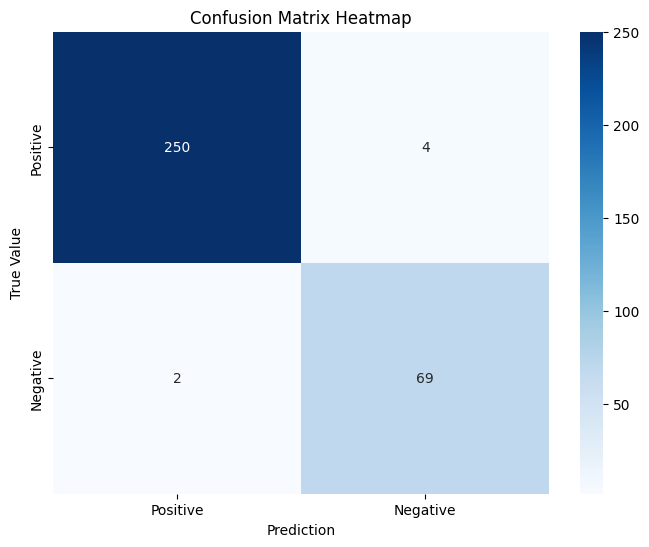

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.xlabel('Prediction')
plt.ylabel('True Value')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid)

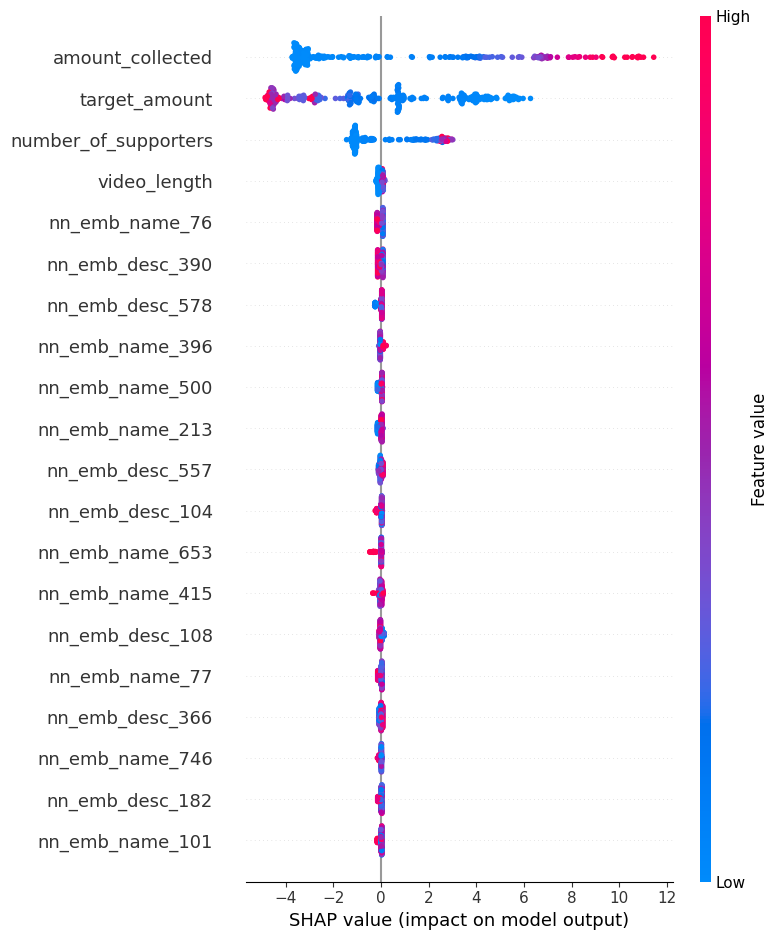

In [ ]:
shap.summary_plot(shap_values, X_valid)

Biểu đồ này thể hiện tầm quan trọng của các đặc trưng (features) trong một mô hình dự đoán, sử dụng giá trị SHAP (SHapley Additive exPlanations) để đo lường ảnh hưởng của từng đặc trưng đến đầu ra của mô hình.


Nhận xét chính

Đặc trưng quan trọng nhất: amount_collected (số tiền đã quyên góp được) có ảnh hưởng mạnh nhất đến đầu ra mô hình, với giá trị SHAP cao nhất và biến động lớn.
Các đặc trưng tài chính khác:
target_amount (mục tiêu quyên góp) cũng có ảnh hưởng đáng kể
number_of_supporters (số người ủng hộ) có tác động tích cực nhưng ít hơn
Các embedding:
Một số embedding từ tên và mô tả có ảnh hưởng đáng kể (các điểm màu đỏ/tím ở xa trục 0)
Đa phần các embedding có ảnh hưởng nhỏ hoặc trung bình
Video length:
- Video_length có ảnh hưởng tương đối nhỏ so với các đặc trưng tài chính    
